In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: ISO-8859-1 encoding is used because restaurant names contain special characters
df = pd.read_csv('zomato.csv', encoding='ISO-8859-1')

# Inspect basic structure
print("--- DATA SHAPE ---")
print(df.shape)
print("\n--- DATA TYPES ---")
print(df.dtypes)
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())
print("\n--- DUPLICATES ---")
print(f"Duplicate rows found: {df.duplicated().sum()}")

# 5-Line Summary Output
print("\n--- DATA SUMMARY ---")
summary = (
    "1. The dataset contains information on thousands of restaurants across multiple countries.\n"
    "2. Key features include restaurant identity, location, cuisines, average costs, and customer ratings.\n"
    "3. Mixed data types are present, including integers, floats, and text objects.\n"
    "4. Minor missing values exist within the 'Cuisines' column which require handling.\n"
    "5. Zero duplicate rows exist, meaning every recorded restaurant entry is unique."
)
print(summary)

--- DATA SHAPE ---
(9551, 21)

--- DATA TYPES ---
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

--- MISSING VALUES ---
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisin

In [2]:
# --- CLEANING DECISION DOCUMENTATION ---
# 1. 'Cuisines': 9 missing values found. We will fill them with 'Unknown' to preserve data rows.
# 2. Drop irrelevant columns: 'Restaurant ID' and 'Country Code' don't offer direct analytical value for localized consumer behavior here.
# 3. 'Switch to order menu': Check if it has variance. If it contains only one value, drop it.

# Execute Cleaning
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

columns_to_drop = ['Restaurant ID', 'Country Code', 'Switch to order menu']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True, errors='ignore')

print("--- POST-CLEANING MISSING VALUES ---")
print(df.isnull().sum())
print(f"\nCleaned Dataset Shape: {df.shape}")

--- POST-CLEANING MISSING VALUES ---
Restaurant Name         0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Cleaned Dataset Shape: (9551, 18)


In [3]:
print("Q1: What are the top 5 most common cuisines listed?")
print(df['Cuisines'].value_counts().head(5))
print("\n" + "="*50 + "\n")

print("Q2: What is the distribution of online delivery availability across restaurants?")
print(df['Has Online delivery'].value_counts())
print("\n" + "="*50 + "\n")

print("Q3: What are the descriptive statistics for average cost for two?")
print(df['Average Cost for two'].describe())
print("\n" + "="*50 + "\n")

print("Q4: Which city has the highest average restaurant rating?")
city_ratings = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)
print(city_ratings.head(5))
print("\n" + "="*50 + "\n")

print("Q5: How many restaurants fall under each unique rating text category?")
print(df['Rating text'].value_counts())

Q1: What are the top 5 most common cuisines listed?
Cuisines
North Indian             936
North Indian, Chinese    511
Fast Food                354
Chinese                  354
North Indian, Mughlai    334
Name: count, dtype: int64


Q2: What is the distribution of online delivery availability across restaurants?
Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64


Q3: What are the descriptive statistics for average cost for two?
count      9551.000000
mean       1199.210763
std       16121.183073
min           0.000000
25%         250.000000
50%         400.000000
75%         700.000000
max      800000.000000
Name: Average Cost for two, dtype: float64


Q4: Which city has the highest average restaurant rating?
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64


Q5: How many restaurants fall under each unique rating text category?

/tmp/ipykernel_5530/1123110102.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0, 0], palette='viridis')


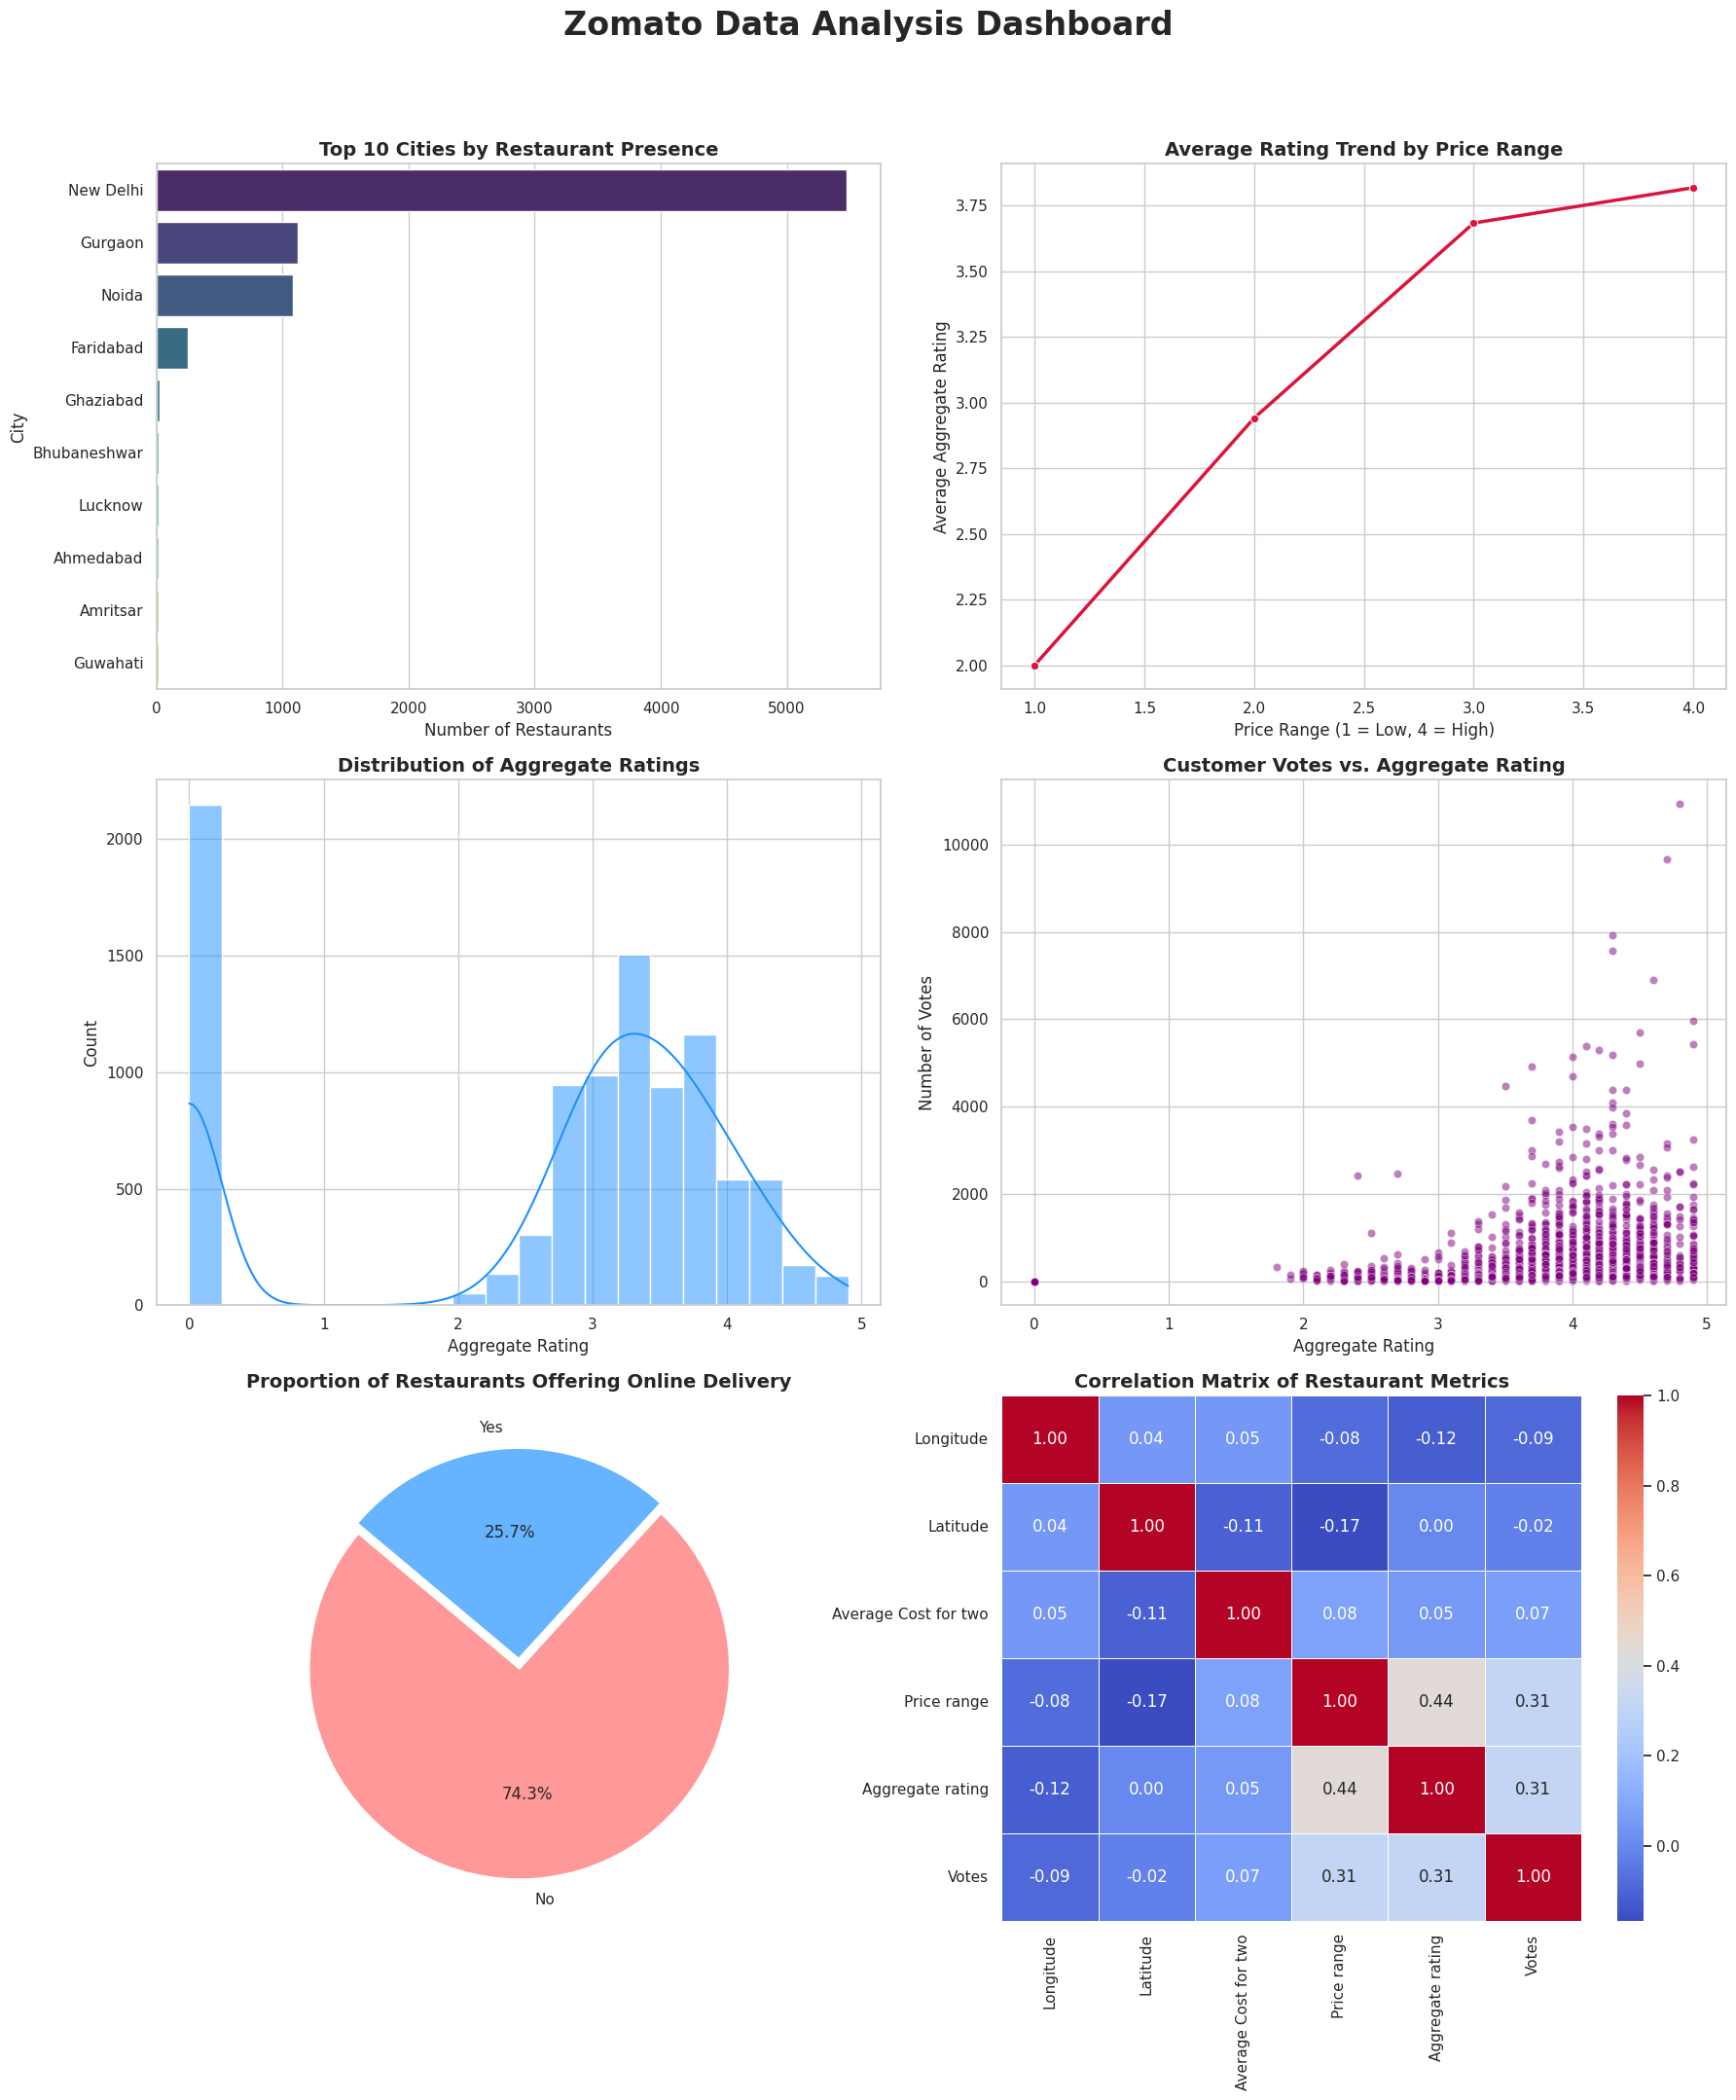

In [4]:
# Set seaborn style for clean aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
fig.suptitle('Zomato Data Analysis Dashboard', fontsize=24, fontweight='bold', y=0.98)

# 1. Bar Chart: Top 10 Cities by Restaurant Count
top_cities = df['City'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top 10 Cities by Restaurant Presence', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Restaurants')
axes[0, 0].set_ylabel('City')

# 2. Line Chart: Average Rating Trends by Price Range
rating_by_price = df.groupby('Price range')['Aggregate rating'].mean().reset_index()
sns.lineplot(data=rating_by_price, x='Price range', y='Aggregate rating', marker='o', color='crimson', linewidth=2.5, ax=axes[0, 1])
axes[0, 1].set_title('Average Rating Trend by Price Range', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Price Range (1 = Low, 4 = High)')
axes[0, 1].set_ylabel('Average Aggregate Rating')

# 3. Histogram: Distribution of Aggregate Ratings
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='dodgerblue', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Aggregate Ratings', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Aggregate Rating')
axes[1, 0].set_ylabel('Count')

# 4. Scatter Plot: Votes vs Aggregate Rating
sns.scatterplot(data=df, x='Aggregate rating', y='Votes', alpha=0.5, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Customer Votes vs. Aggregate Rating', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Aggregate Rating')
axes[1, 1].set_ylabel('Number of Votes')

# 5. Pie Chart: Has Online Delivery Distribution
delivery_counts = df['Has Online delivery'].value_counts()
axes[2, 0].pie(delivery_counts, labels=delivery_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
axes[2, 0].set_title('Proportion of Restaurants Offering Online Delivery', fontsize=14, fontweight='bold')

# 6. Heatmap: Correlation between Numeric Variables
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[2, 1])
axes[2, 1].set_title('Correlation Matrix of Restaurant Metrics', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [5]:
report = """
## INSIGHTS REPORT

1. **Market Concentration**: The bar chart reveals that a massive majority of restaurants in this dataset are heavily concentrated in specific cities (like New Delhi), showing an aggressive regional market penetration strategy.
2. **Premium Price Premium Quality**: The line chart clearly shows a positive linear correlation between price range and aggregate ratings. Higher-priced restaurants consistently score better reviews, potentially due to better service and food quality.
3. **The 'Zero-Rating' Anomaly**: The histogram displays a major spike of restaurants with a '0.0' rating. This points to unrated or brand-new restaurants rather than uniformly terrible performance across thousands of locations.
4. **Engagement Drives Validation**: The scatter plot shows that restaurants with higher aggregate ratings (between 3.5 and 4.5) attract exponentially higher vote counts, demonstrating that highly-rated venues enjoy far superior customer engagement.
5. **Untapped Delivery Infrastructure**: The pie chart states that over 74% of restaurants do not offer online delivery. This represents a massive revenue expansion opportunity for Zomato to onboard these offline-only venues.

---

### Surprising Finding
"What surprised me the most was the massive volume of restaurants sitting exactly at a 0.0 aggregate rating in the histogram. Initially, this looks like poor restaurant quality across the board, but cross-referencing it with vote data reveals these are simply unrated, newly-listed venues. This highlights how critical it is to clean and contextually interpret data anomalies before drawing quick conclusions."
"""
print(report)


## INSIGHTS REPORT

1. **Market Concentration**: The bar chart reveals that a massive majority of restaurants in this dataset are heavily concentrated in specific cities (like New Delhi), showing an aggressive regional market penetration strategy.
2. **Premium Price Premium Quality**: The line chart clearly shows a positive linear correlation between price range and aggregate ratings. Higher-priced restaurants consistently score better reviews, potentially due to better service and food quality.
3. **The 'Zero-Rating' Anomaly**: The histogram displays a major spike of restaurants with a '0.0' rating. This points to unrated or brand-new restaurants rather than uniformly terrible performance across thousands of locations.
4. **Engagement Drives Validation**: The scatter plot shows that restaurants with higher aggregate ratings (between 3.5 and 4.5) attract exponentially higher vote counts, demonstrating that highly-rated venues enjoy far superior customer engagement.
5. **Untapped Deliv